# Understanding the Histogram

A histogram divides a numerical variable into equal-width **bins** and shows how many observations fall into each bin. It is the most direct way to see the *shape* of a distribution.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

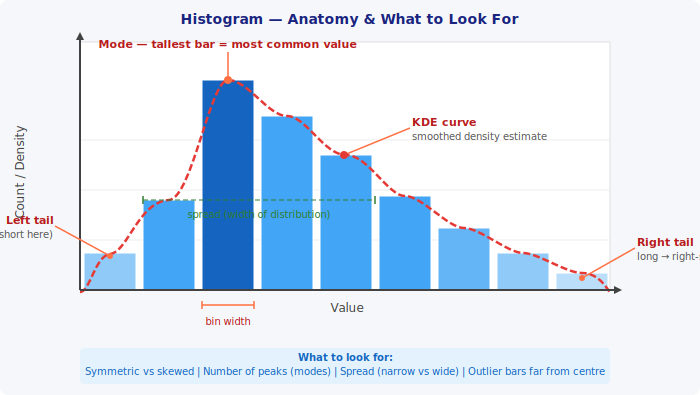

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="395"
     font-family="'Segoe UI', Arial, sans-serif">

  <!-- background -->
  <rect width="700" height="395" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Histogram — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="80" y="42" width="530" height="248" fill="white" stroke="#E0E0E0" stroke-width="1"/>

  <!-- gridlines -->
  <line x1="80" y1="140" x2="610" y2="140" stroke="#EEEEEE" stroke-width="1"/>
  <line x1="80" y1="190" x2="610" y2="190" stroke="#EEEEEE" stroke-width="1"/>
  <line x1="80" y1="240" x2="610" y2="240" stroke="#EEEEEE" stroke-width="1"/>

  <!-- bars: right-skewed, 9 bars, barW=52, step=59 -->
  <!-- bar0 --><rect x="84"  y="253" width="52" height="37"  fill="#90CAF9" stroke="white" stroke-width="1"/>
  <!-- bar1 --><rect x="143" y="200" width="52" height="90"  fill="#42A5F5" stroke="white" stroke-width="1"/>
  <!-- bar2 MODE --><rect x="202" y="80"  width="52" height="210" fill="#1565C0" stroke="white" stroke-width="1"/>
  <!-- bar3 --><rect x="261" y="116" width="52" height="174" fill="#42A5F5" stroke="white" stroke-width="1"/>
  <!-- bar4 --><rect x="320" y="155" width="52" height="135" fill="#42A5F5" stroke="white" stroke-width="1"/>
  <!-- bar5 --><rect x="379" y="196" width="52" height="94"  fill="#42A5F5" stroke="white" stroke-width="1"/>
  <!-- bar6 --><rect x="438" y="228" width="52" height="62"  fill="#64B5F6" stroke="white" stroke-width="1"/>
  <!-- bar7 --><rect x="497" y="253" width="52" height="37"  fill="#90CAF9" stroke="white" stroke-width="1"/>
  <!-- bar8 --><rect x="556" y="273" width="52" height="17"  fill="#BBDEFB" stroke="white" stroke-width="1"/>

  <!-- KDE curve (smooth red-dashed) -->
  <path d="M 80,292 C 90,292 95,256 110,254 C 128,252 138,202 169,200
            C 192,198 210,80 228,80 C 248,80 268,116 287,116
            C 306,116 324,155 346,155 C 368,155 388,196 405,196
            C 422,196 448,228 464,228 C 480,228 508,253 523,253
            C 538,253 566,273 582,273 C 600,273 608,291 610,292"
        fill="none" stroke="#E53935" stroke-width="2.5" stroke-dasharray="7,3"/>

  <!-- axes -->
  <line x1="80" y1="290" x2="614" y2="290" stroke="#424242" stroke-width="2"/>
  <line x1="80" y1="290" x2="80"  y2="40"  stroke="#424242" stroke-width="2"/>
  <polygon points="614,286 622,290 614,294" fill="#424242"/>
  <polygon points="76,40 80,32 84,40"       fill="#424242"/>

  <!-- axis labels -->
  <text x="347" y="312" text-anchor="middle" font-size="12" fill="#424242">Value</text>
  <text x="24" y="172" text-anchor="middle" font-size="12" fill="#424242"
        transform="rotate(-90 24 172)">Count / Density</text>

  <!-- ── ANNOTATIONS ── -->

  <!-- 1. Mode: arrow up from tallest bar -->
  <line x1="228" y1="80" x2="228" y2="52" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="228" cy="80" r="4" fill="#FF7043"/>
  <text x="228" y="48" text-anchor="middle" font-size="11" font-weight="bold"
        fill="#B71C1C">Mode — tallest bar = most common value</text>

  <!-- 2. Right tail -->
  <line x1="582" y1="278" x2="635" y2="248" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="582" cy="278" r="3" fill="#FF7043"/>
  <text x="637" y="246" font-size="11" font-weight="bold" fill="#B71C1C">Right tail</text>
  <text x="637" y="260" font-size="10" fill="#555">long → right-skewed</text>

  <!-- 3. Left tail -->
  <line x1="110" y1="256" x2="55" y2="226" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="110" cy="256" r="3" fill="#FF7043"/>
  <text x="53" y="224" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Left tail</text>
  <text x="53" y="238" text-anchor="end" font-size="10" fill="#555">(short here)</text>

  <!-- 4. Bin width bracket -->
  <line x1="202" y1="305" x2="254" y2="305" stroke="#FF7043" stroke-width="1.5"/>
  <line x1="202" y1="301" x2="202" y2="309" stroke="#FF7043" stroke-width="1.5"/>
  <line x1="254" y1="301" x2="254" y2="309" stroke="#FF7043" stroke-width="1.5"/>
  <text x="228" y="325" text-anchor="middle" font-size="10" fill="#B71C1C">bin width</text>

  <!-- 5. KDE label -->
  <line x1="344" y1="155" x2="410" y2="128" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="344" cy="155" r="4" fill="#E53935"/>
  <text x="412" y="126" font-size="11" font-weight="bold" fill="#B71C1C">KDE curve</text>
  <text x="412" y="140" font-size="10" fill="#555">smoothed density estimate</text>

  <!-- 6. Spread bracket across two bars that flank the peak -->
  <line x1="143" y1="200" x2="375" y2="200" stroke="#2E7D32" stroke-width="1" stroke-dasharray="5,3"/>
  <line x1="143" y1="196" x2="143" y2="204" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="375" y1="196" x2="375" y2="204" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="259" y="218" text-anchor="middle" font-size="10" fill="#2E7D32">spread (width of distribution)</text>

  <!-- takeaway bar -->
  <rect x="80" y="348" width="530" height="36" fill="#E3F2FD" rx="4"/>
  <text x="345" y="361" text-anchor="middle" font-size="10" fill="#1565C0" font-weight="bold">What to look for:</text>
  <text x="345" y="375" text-anchor="middle" font-size="10" fill="#1565C0">Symmetric vs skewed  |  Number of peaks (modes)  |  Spread (narrow vs wide)  |  Outlier bars far from centre</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Histogram

| Feature | What it tells you |
|---|---|
| **Tallest bar** | Mode — the most common value range |
| **Symmetric bell** | Data is approximately normally distributed |
| **Long right tail** | Right-skewed — a few very large values pull the mean up |
| **Long left tail** | Left-skewed — a few very small values pull the mean down |
| **Two peaks** | Bimodal — likely two distinct subpopulations |
| **Wide / narrow** | High / low dispersion (std is large / small) |
| **Isolated bar far from the rest** | Potential outlier cluster |

**Bin width matters**: too few bins hides structure; too many bins adds noise. A good default is 20–30 bins, or let the library choose automatically.

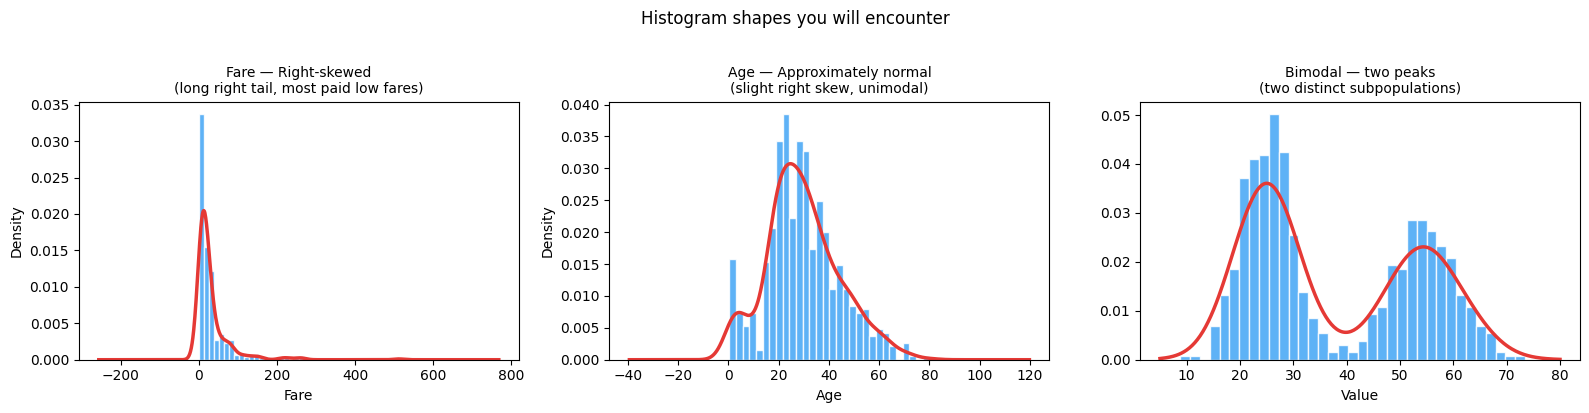

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Right-skewed: fare
axes[0].hist(df['fare'].dropna(), bins=40, color='#42A5F5', edgecolor='white', alpha=0.85, density=True)
df['fare'].dropna().plot.kde(ax=axes[0], color='#E53935', linewidth=2.5)
axes[0].set_title('Fare — Right-skewed\n(long right tail, most paid low fares)', fontsize=10)
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Density')

# Roughly symmetric: age
axes[1].hist(df['age'].dropna(), bins=30, color='#42A5F5', edgecolor='white', alpha=0.85, density=True)
df['age'].dropna().plot.kde(ax=axes[1], color='#E53935', linewidth=2.5)
axes[1].set_title('Age — Approximately normal\n(slight right skew, unimodal)', fontsize=10)
axes[1].set_xlabel('Age')

# Bimodal: mix two normals
np.random.seed(42)
bimodal = np.concatenate([np.random.normal(25, 5, 400), np.random.normal(55, 6, 300)])
axes[2].hist(bimodal, bins=35, color='#42A5F5', edgecolor='white', alpha=0.85, density=True)
import scipy.stats as stats
xr = np.linspace(5, 80, 300)
kde = stats.gaussian_kde(bimodal)
axes[2].plot(xr, kde(xr), color='#E53935', linewidth=2.5)
axes[2].set_title('Bimodal — two peaks\n(two distinct subpopulations)', fontsize=10)
axes[2].set_xlabel('Value')

plt.suptitle('Histogram shapes you will encounter', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

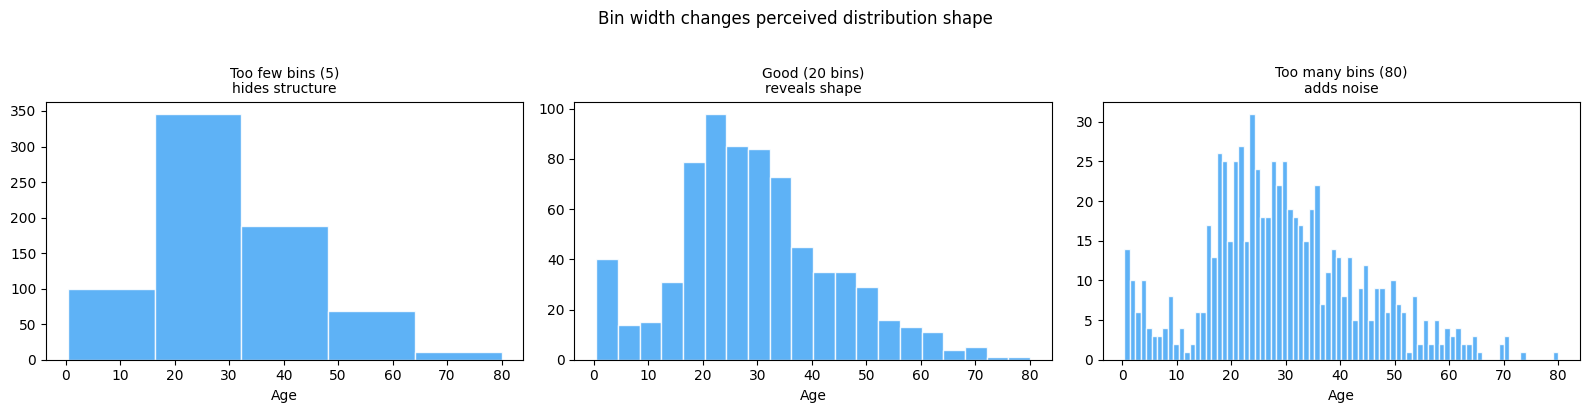

In [4]:
# Effect of bin width on perceived shape
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
age = df['age'].dropna()

for ax, bins, label in zip(axes,
    [5, 20, 80],
    ['Too few bins (5)\nhides structure', 'Good (20 bins)\nreveals shape', 'Too many bins (80)\nadds noise']):
    ax.hist(age, bins=bins, color='#42A5F5', edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Age')

plt.suptitle('Bin width changes perceived distribution shape', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Single numerical variable — distribution shape |
| **Mode** | Tallest bar |
| **Skewness** | Direction of the longer tail |
| **Bimodal** | Two distinct peaks → two subpopulations |
| **KDE** | Smooth version — less sensitive to bin width |
| **Bin width** | Too few: over-smooth; too many: over-noisy |